# First-pass analytics
After running the first pass of trainings with configuration:
```shell
ITERATIONS=(500 1000 1500 2000)
TRAIN_BATCH_SIZES=(2000 3000 4000)
NUM_SGD_ITERS=(3 5 10)
ENTROPY_VALUES=(0.0 0.1 0.05 0.2 0.3)
```

We didn't achieve a good result and hence required another set of hyperparameter sweep with a fine-tuned search space. Our approach for finding better hyperparameters was to use the training result in the first pass as a basis for trend extraction and then search-space prunning. This notebook aims to explore the `logs_processed/aggregated.csv` file and answer make decision on the next set of parameters that will be used in the second-pass of the hyperparameter sweeps.

## Setup and load dataset

Do basic imports and load the `aggregated.csv` file.

In [48]:
from pathlib import Path

from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [49]:
data_path = Path('../logs_processed/aggregated.csv')
df = pd.read_csv(data_path)

df.head()

,job_id,iteration,train_batch_size,sgd_minibatch_size,entropy,max_reward,is_target_reached,is_training_stable
0,0,500,2000,3,0.00,6.33,True,True
1,1,500,2000,3,0.10,0.80,False,False
2,2,500,2000,3,0.05,1.32,False,True
3,3,500,2000,3,0.20,0.80,False,False
4,4,500,2000,3,0.30,0.93,False,False


## Reward distribution by entropy coefficient

Box plot showing:
- x-axis: entropy
- y-axis: max_reward
- color: is_training_stable
- horizontal line: reward = 6.0


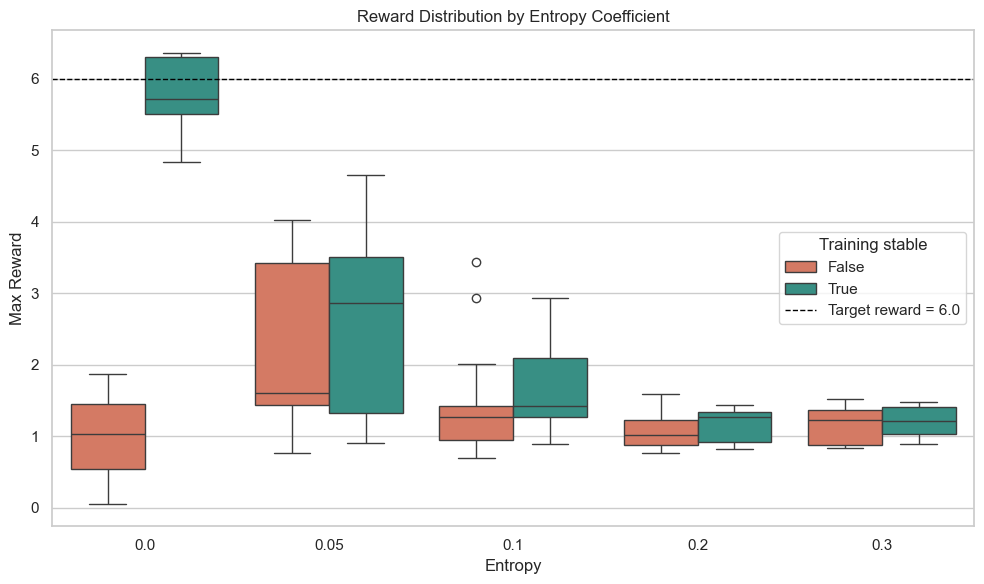

In [50]:
sns.set_theme(style='whitegrid')

entropy_order = sorted(df['entropy'].unique())

plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df,
    x='entropy',
    y='max_reward',
    hue='is_training_stable',
    order=entropy_order,
    palette={True: '#2a9d8f', False: '#e76f51'}
)

ax.axhline(6.0, color='black', linestyle='--', linewidth=1, label='Target reward = 6.0')
ax.set_title('Reward Distribution by Entropy Coefficient')
ax.set_xlabel('Entropy')
ax.set_ylabel('Max Reward')
ax.legend(title='Training stable')
plt.tight_layout()
plt.show()


This diagram shows a **decreasing reward gain trend** when **entropy is increased**. The most achieved reward is when entropy is set to 0 and 5%, which clearly shows that the optimal reward is between those values. Hence, I think a suitable entropy parameter sweep would be:
```python
entropy = [0.0, 0.0025, 0.005, 0.01, 0.02, 0.03, 0.05]
```

Moreover, let's explore other parameter's effect on achieved performance.

## Heatmaps of reward for parameter interactions

Using a heatmap we can explore the effect of other hyperparameters on the achieved performance. Below is a list of most useful heatmaps:
- train_batch_size × sgd_minibatch_size, faceted by entropy
- iteration × train_batch_size, faceted by entropy
- iteration × sgd_minibatch_size, faceted by entropy

We will use `max_reward` as the number represented by each cell as it is easier to understand and reason about.


In [51]:
def plot_entropy_faceted_heatmaps(data, row_col, col_col, title, row_label, col_label):
    entropy_values = sorted(data['entropy'].unique())
    vmin = data['max_reward'].min()
    vmax = data['max_reward'].max()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for index, entropy_value in enumerate(entropy_values):
        subset = data[data['entropy'] == entropy_value]
        pivot = subset.pivot_table(
            index=row_col,
            columns=col_col,
            values='max_reward',
            aggfunc='mean'
        )
        pivot = pivot.reindex(index=sorted(pivot.index), columns=sorted(pivot.columns))
        pivot['Mean'] = pivot.mean(axis=1)
        pivot.loc['Mean'] = pivot.mean(axis=0)

        mean_mask = pd.DataFrame(False, index=pivot.index, columns=pivot.columns)
        mean_mask.loc['Mean', :] = True
        mean_mask.loc[:, 'Mean'] = True
        main_mask = mean_mask
        summary_mask = ~mean_mask

        ax = axes[index]
        sns.heatmap(
            pivot,
            ax=ax,
            annot=True,
            fmt='.2f',
            cmap='YlGnBu',
            vmin=vmin,
            vmax=vmax,
            linewidths=0.5,
            mask=main_mask,
            cbar=index == 0,
            cbar_kws={'label': 'Max Reward'}
        )

        sns.heatmap(
            pivot,
            ax=ax,
            annot=True,
            fmt='.2f',
            cmap=ListedColormap(['white']),
            linewidths=0.5,
            mask=summary_mask,
            cbar=False
        )

        ax.set_title(f'Entropy = {entropy_value}')
        ax.set_xlabel(col_label)
        ax.set_ylabel(row_label)

    for ax in axes[len(entropy_values):]:
        ax.axis('off')

    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


### train_batch_size × sgd_minibatch_size, faceted by entropy


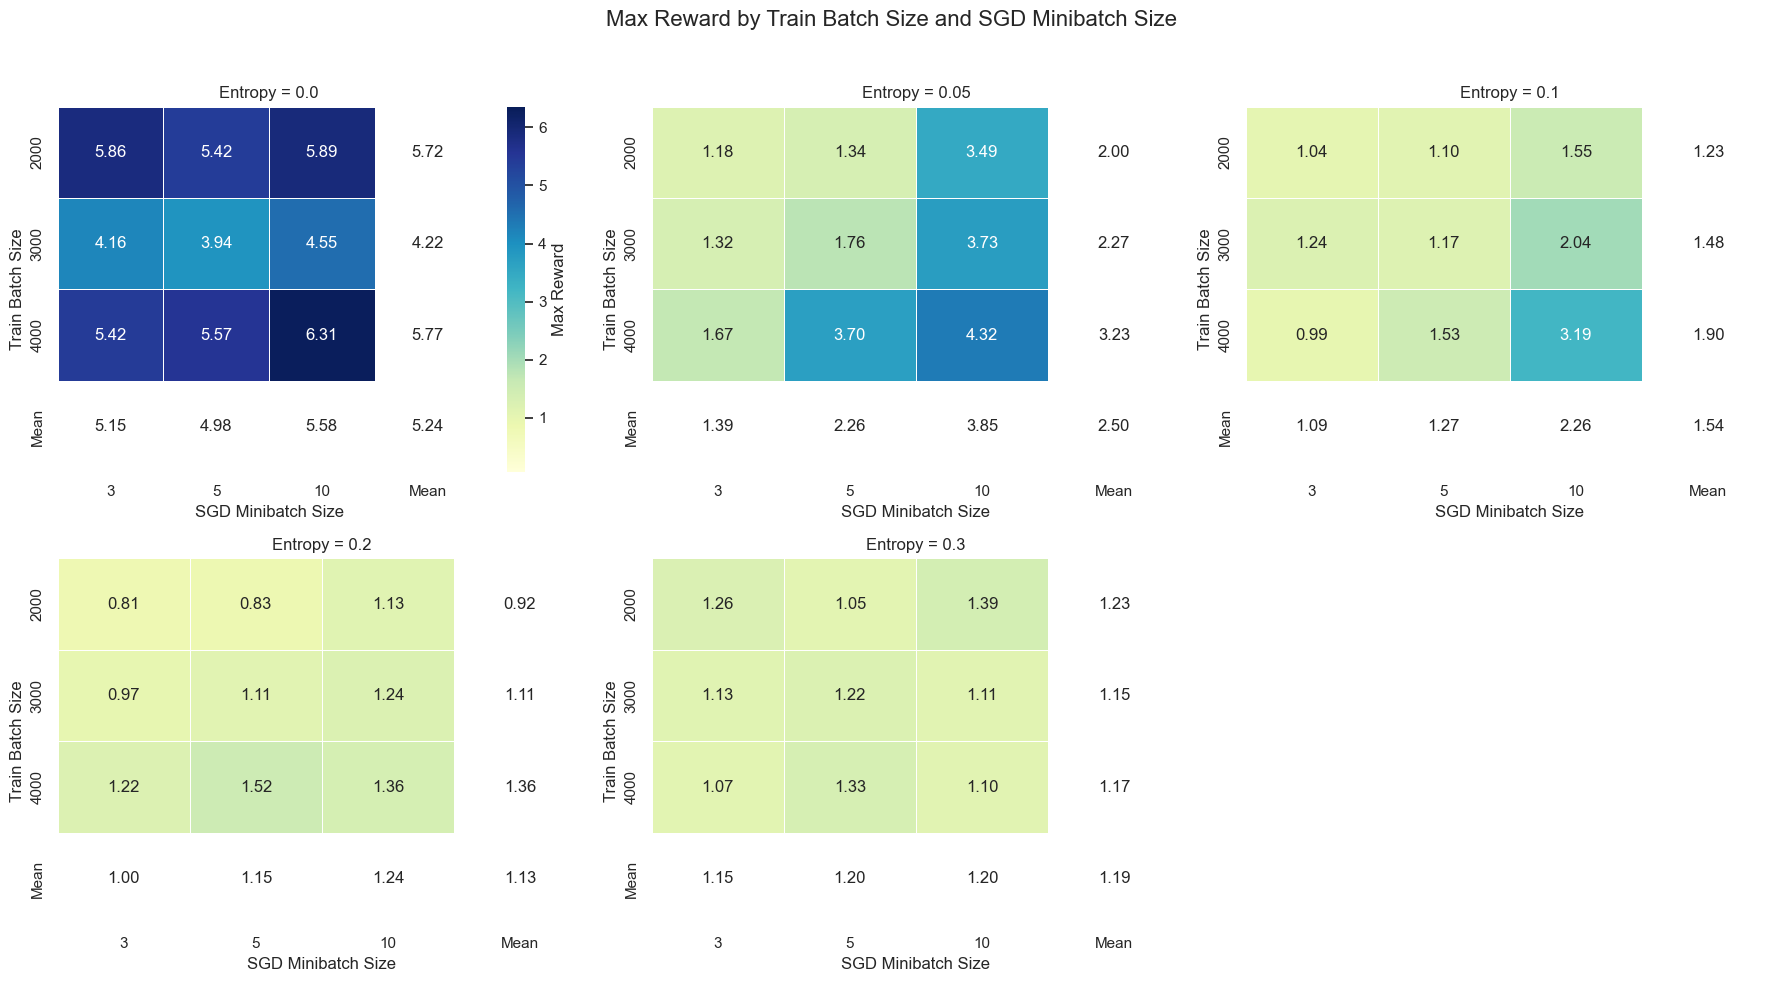

In [52]:
plot_entropy_faceted_heatmaps(
    data=df,
    row_col='train_batch_size',
    col_col='sgd_minibatch_size',
    title='Max Reward by Train Batch Size and SGD Minibatch Size',
    row_label='Train Batch Size',
    col_label='SGD Minibatch Size'
)


The most important heatmap box is the one related to 0 and 5% entropies as we have chosen this range for our second-pass. Based on this two boxes we can see:
- increasing train_batch_size has caused almost monotonic increase in achieved performance
- increasing sgd_minibatch_size has caused almost monotonic increase in achieved performance

Our opinion is that:
- train_batch_size: 4000
- sgd_minibatch_size: 10

can be selected for the second-pass; however, if there is time for a third-pass some exploration should be done on these features

### iteration × train_batch_size, faceted by entropy


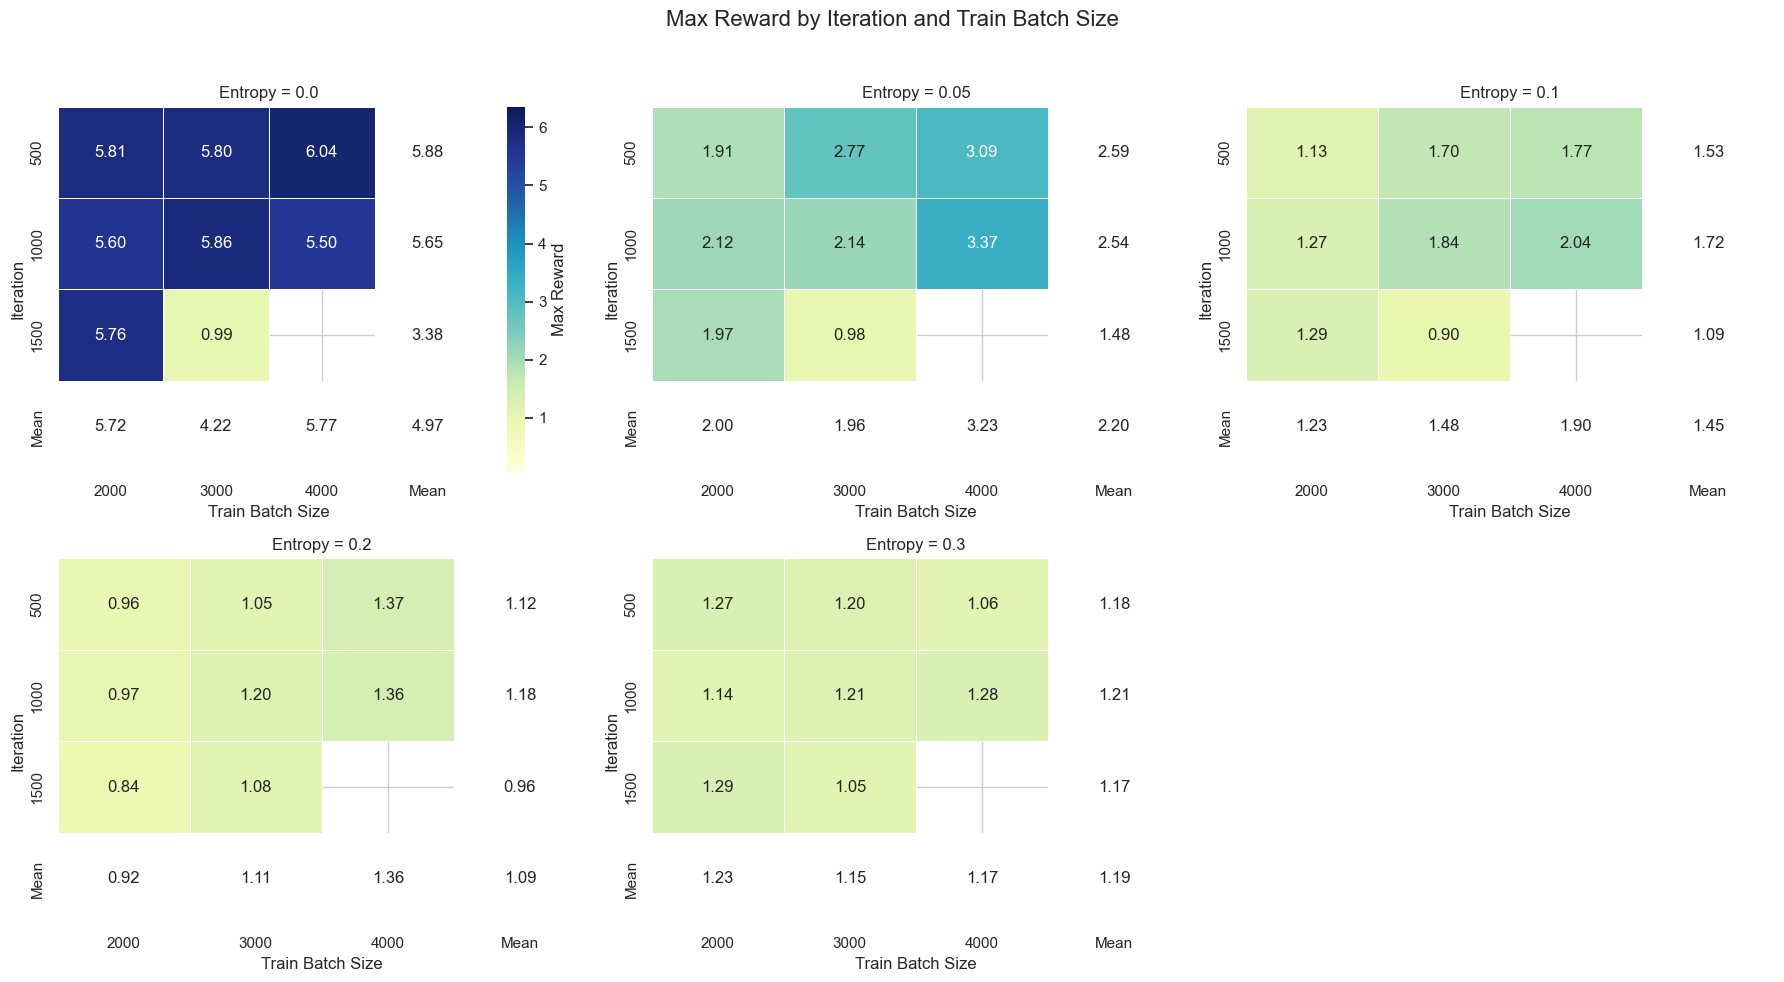

In [53]:
plot_entropy_faceted_heatmaps(
    data=df,
    row_col='iteration',
    col_col='train_batch_size',
    title='Max Reward by Iteration and Train Batch Size',
    row_label='Iteration',
    col_label='Train Batch Size'
)


Here we have an unintuitive observation. By increasing iterations, the achieved performance of the system has decreased! This is unintuitive as we expect by increasing the learning possibility a better policy should be created.

Our explanation for the observation is that due to the fact that our parameters haven't been stable enough, the increased learning opportunity has given the policy more time to decrease. So, if we wind a better combination of parameters that achieve a better reward, we expect higher iteration count causing higher achieved rewards.

Based on this we conclude that for the second-pass we will have:
- iterations: 500

But for the other passes we will experiment with higher iteration values

### iteration × sgd_minibatch_size, faceted by entropy


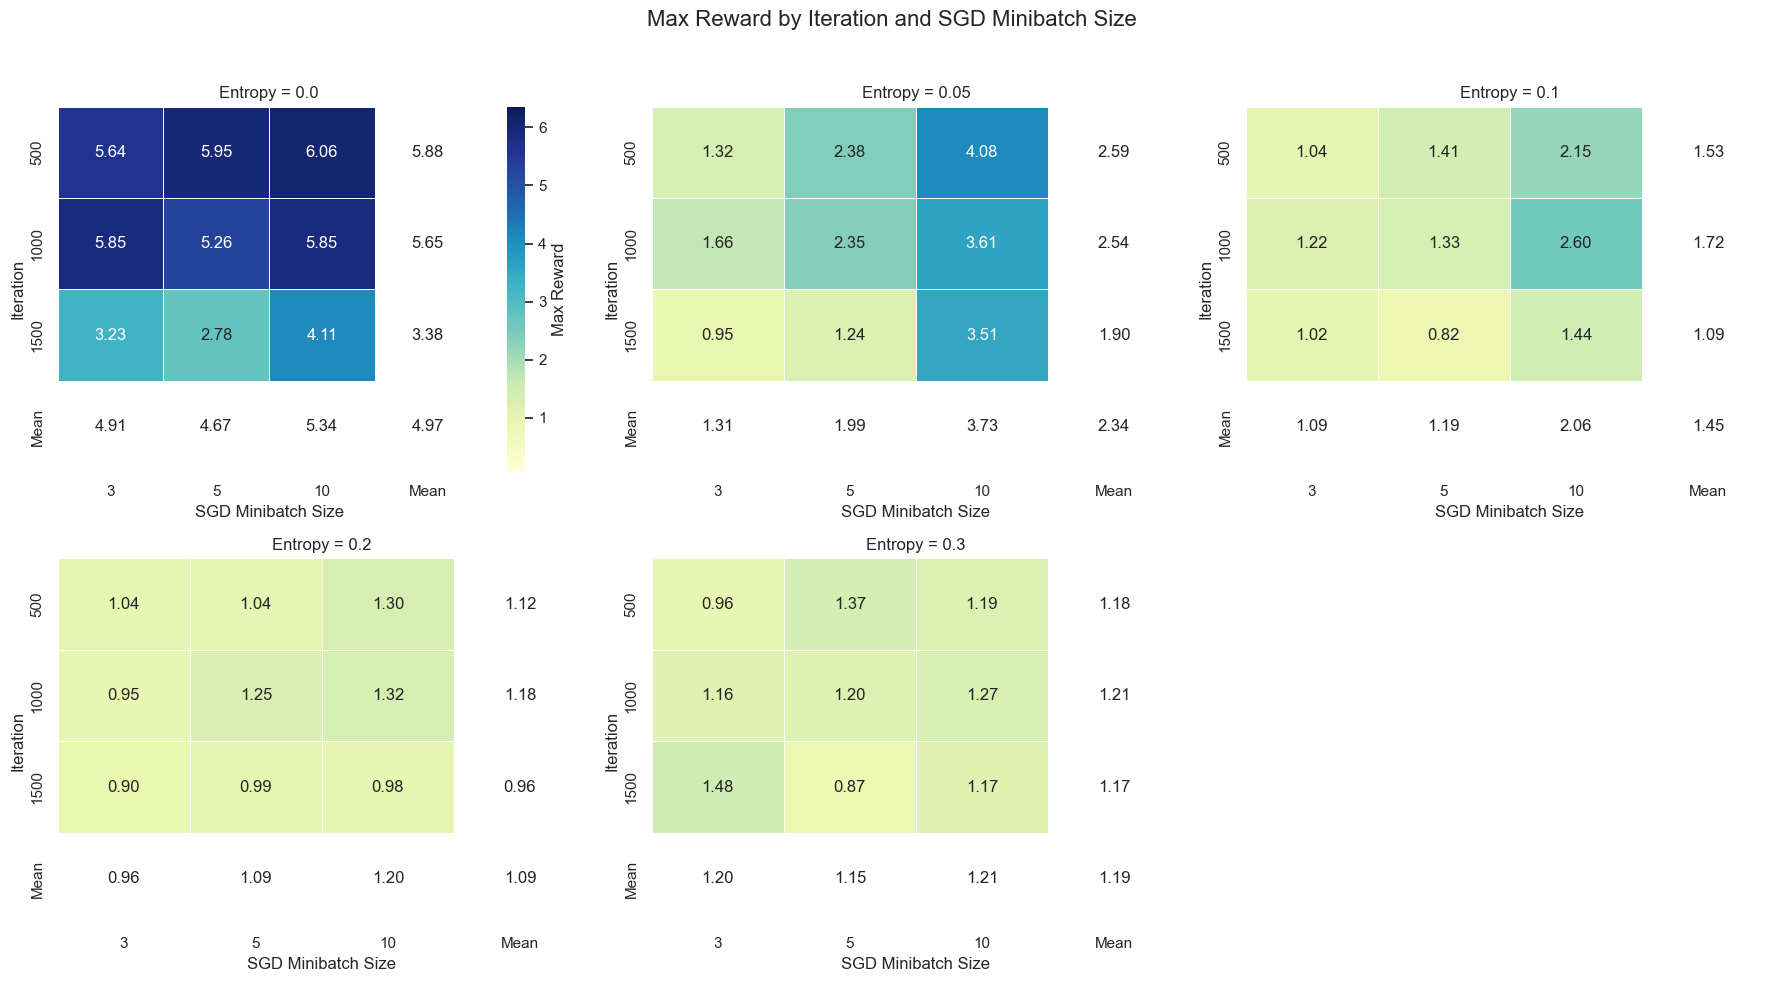

In [54]:
plot_entropy_faceted_heatmaps(
    data=df,
    row_col='iteration',
    col_col='sgd_minibatch_size',
    title='Max Reward by Iteration and SGD Minibatch Size',
    row_label='Iteration',
    col_label='SGD Minibatch Size'
)


This heatmap just reinforces our choices of iteration and sgd_minibatch_size. We can observe that by lowering the iterations to 500 and increasing the sgd_minibatch_size to 10 we have been able to achieve higher performance. Thus, this hyperparameter configuration can be selected:
- iterations: 500
- sgd_minibatch_size: 10

## Scatter plot of reward versus total sampled environment steps

## Ranked top-k configuration plot

## Stability-rate plots

## Make final decision